# Evaluación final, análisis de errores y conclusiones

**Lo que pide el enunciado y dónde está:**

| Pide | Dónde |
|---|---|
| §14 Tabla final de todos los experimentos | §1 |
| §12 Top-1, Top-5, Macro-F1, Weighted-F1; rendimiento por grupo taxonómico | §1, §2 |
| §13 Análisis de errores del mejor modelo: confianza alta/baja, especies confundidas, casos difíciles, patrones interpretables | §3 |
| §3 Pregunta de investigación e hipótesis; conclusiones y limitaciones (§16.3) | §4 |

Como la validación está balanceada (10 imágenes por especie), el *weighted F1* coincide con el *macro F1*.
Se reportan ambos porque lo pide el enunciado.

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

import datos
from config import CACHE, RES_ALMACEN
from sklearn.metrics import f1_score
va = datos.indice("val")
especies = va.drop_duplicates("etiqueta").set_index("etiqueta").sort_index()

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Tabla final de experimentos (§14)

In [2]:
final = tabla(R, [c.id for c in EXPERIMENTOS])
cfg = pd.DataFrame([dict(ID=c.id, modelo=c.modelo, optimizador=f"{c.optimizador} {c.lr:g}",
        regularización=", ".join(x for x, on in [("BN", c.bn and c.modelo != "mlp"), (f"drop {c.dropout}", c.dropout > 0),
                                                  (f"wd {c.weight_decay:g}", c.weight_decay > 0),
                                                  (f"LS {c.label_smoothing}", c.label_smoothing > 0)] if on),
        aug=c.aumento, transfer=c.ajuste if c.preentrenado else "no",
        long_tail={"completo": "no", "longtail": "sí", "lt_balanceado": "control"}[c.datos],
        mitigación={"ce": "", "ce_ponderada": "CE pond.", "logit_ajustado": "logit adj."}[c.perdida]
                   + (" WS" if c.muestreo == "ponderado" else ""))
    for c in EXPERIMENTOS]).set_index("ID")
T = cfg.join(final[["top1", "top5", "f1_macro", "f1_weighted", "params_M", "min_total", "gpu"]], how="left")
T.style.format(FMT, na_rep="—")

,modelo,optimizador,regularización,aug,transfer,long_tail,mitigación,top1,top5,f1_macro,f1_weighted,params_M,min_total,gpu
ID,,,,,,,,,,,,,,
E01,mlp,adam 0.001,,ninguno,no,no,,1.1%,3.4%,0.8%,0.8%,18.6,8,RTX A6000
E02,mlp,adam 0.001,,ninguno,no,no,,1.0%,3.2%,0.6%,0.6%,37.5,5,A100 MIG 2g.10gb
E03,resnet18,sgdm 0.1,"BN, wd 5e-05",basico,no,no,,32.4%,54.5%,31.8%,31.8%,16.3,27,RTX A6000
E04,resnet50,sgdm 0.1,"BN, wd 5e-05",basico,no,no,,37.6%,60.4%,37.1%,37.1%,44.0,75,RTX A6000
E05,efficientnet_b0,sgdm 0.1,"BN, wd 5e-05",basico,no,no,,37.0%,60.0%,36.3%,36.3%,16.8,37,RTX A6000
E06,resnet18,sgd 0.1,"BN, wd 5e-05",basico,no,no,,17.3%,35.6%,15.8%,15.8%,16.3,19,A100 MIG 3g.20gb
E07,resnet18,sgdm 0.02,"BN, wd 5e-05",basico,no,no,,25.9%,46.9%,24.8%,24.8%,16.3,19,A100 MIG 3g.20gb
E08,resnet18,sgdm 0.5,"BN, wd 5e-05",basico,no,no,,34.7%,56.6%,34.3%,34.3%,16.3,19,A100 MIG 3g.20gb
E09,resnet18,adam 0.001,"BN, wd 5e-05",basico,no,no,,32.6%,54.8%,32.0%,32.0%,16.3,20,A100 MIG 3g.20gb


## 2. Rendimiento por grupo taxonómico (mejor modelo)

In [3]:
candidatos = [i for i in ["T3", "T4", "T2", "E04"] if i in R]
MEJOR = max(candidatos, key=lambda i: R[i]["resumen"]["val_top1"])
print("mejor modelo:", MEJOR, "·", POR_ID[MEJOR].descripcion, f"· top-1 {R[MEJOR]['resumen']['val_top1']:.1%}")
p = np.load(R[MEJOR]["dir"] / "preds.npz")
y, top5, prob5 = p["y"], p["top5"].astype(int), p["prob5"].astype(np.float32)
df = va.iloc[p["idx_val"]].reset_index(drop=True).assign(
    pred=top5[:, 0], conf=prob5[:, 0], ok=top5[:, 0] == y, ok5=(top5 == y[:, None]).any(1))
taxo = df.groupby("supercategory").agg(especies=("etiqueta", "nunique"), top1=("ok", "mean"),
                                       top5=("ok5", "mean"), confianza=("conf", "mean")).sort_values("top1")
taxo["f1_macro"] = [f1_score(df.etiqueta[df.supercategory == s], df.pred[df.supercategory == s],
                             labels=df.etiqueta[df.supercategory == s].unique(), average="macro", zero_division=0)
                    for s in taxo.index]
taxo.style.format({"top1": "{:.1%}", "top5": "{:.1%}", "confianza": "{:.2f}", "f1_macro": "{:.1%}"})

mejor modelo: T3 · C: Full Fine-Tuning · top-1 50.4%


,especies,top1,top5,confianza,f1_macro
supercategory,,,,,
Amphibians,170,29.3%,55.0%,0.56,32.0%
Reptiles,313,31.4%,56.1%,0.55,34.2%
Birds,1486,42.2%,64.6%,0.61,43.0%
Mammals,246,44.1%,67.5%,0.63,47.5%
Arachnids,153,45.9%,72.0%,0.63,50.5%
Plants,4271,49.0%,70.4%,0.64,49.3%
Ray-finned Fishes,183,52.6%,74.5%,0.67,54.8%
Animalia,142,54.1%,78.3%,0.67,59.1%
Fungi,341,56.7%,82.5%,0.70,59.2%


In [4]:
# ¿La dificultad de un grupo se explica por cuántas especies congenéricas tiene?
esp = especies.reset_index()
esp["congenéricas"] = esp.groupby("genus").etiqueta.transform("size") - 1
acc_esp = df.groupby("etiqueta").ok.mean()
esp["top1"] = acc_esp.reindex(esp.etiqueta).to_numpy()
t = esp.groupby(pd.cut(esp.congenéricas, [-1, 0, 2, 5, 10, 100], labels=["0", "1–2", "3–5", "6–10", ">10"]),
                observed=True).agg(especies=("top1", "size"), top1=("top1", "mean"))
t.index.name = "nº de especies del mismo género"
t.style.format({"top1": "{:.1%}"})

,especies,top1
nº de especies del mismo género,,
0,3158,56.1%
1–2,2695,51.4%
3–5,1631,45.6%
6–10,984,45.6%
>10,1532,45.5%


## 3. Análisis de errores (§13)

### 3.1 ¿A qué distancia taxonómica están los errores?
Para cada error, el nivel más bajo que comparten la especie real y la predicha. Si la mayoría comparte
género, el modelo falla en lo genuinamente fine-grained. Si caen en otro reino, son errores de "atajo"
(fondo, contexto).

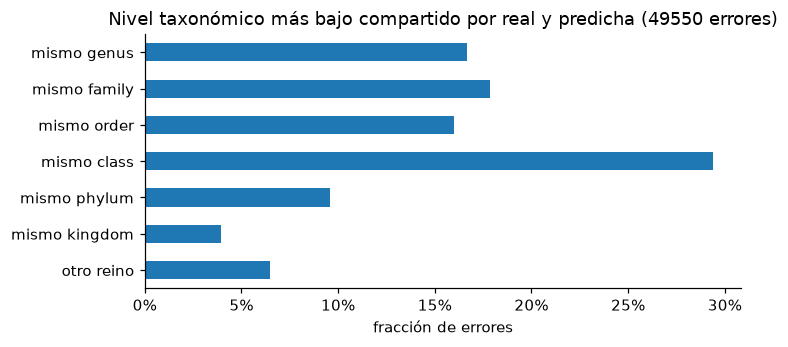

errores con la especie correcta dentro del top-5: 43.7%


,mismo genus,mismo family,mismo order,mismo class,mismo phylum,mismo kingdom,otro reino
fracción de errores,16.7%,17.9%,16.0%,29.4%,9.6%,4.0%,6.5%


In [5]:
niveles = ["genus", "family", "order", "class", "phylum", "kingdom"]
E = df[~df.ok]
er, ep_ = especies.loc[E.etiqueta], especies.loc[E.pred]
comparte = pd.Series("otro reino", index=E.index)
for n in reversed(niveles):
    comparte[er[n].to_numpy() == ep_[n].to_numpy()] = f"mismo {n}"
dist = comparte.value_counts(normalize=True).reindex([f"mismo {n}" for n in niveles] + ["otro reino"]).fillna(0)
ax = dist.plot.barh(figsize=(7, 3)); ax.invert_yaxis(); ax.set_xlabel("fracción de errores")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(f"Nivel taxonómico más bajo compartido por real y predicha ({len(E)} errores)"); plt.show()
print(f"errores con la especie correcta dentro del top-5: {E.ok5.mean():.1%}")
dist.map("{:.1%}".format).to_frame("fracción de errores").T

### 3.2 Pares de especies más confundidos

In [6]:
(E.assign(real=especies.especie.loc[E.etiqueta].to_numpy(), predicha=especies.especie.loc[E.pred].to_numpy(),
          grupo=E.supercategory, mismo_género=(er.genus.to_numpy() == ep_.genus.to_numpy()))
  .groupby(["real", "predicha", "grupo", "mismo_género"]).size().sort_values(ascending=False).head(15)
  .to_frame("veces (de 10 imágenes)"))

,,,,veces (de 10 imágenes)
real,predicha,grupo,mismo_género,
Burnsius albescens,Burnsius communis,Insects,True,7
Nyctibius griseus,Nyctibius jamaicensis,Birds,True,7
Aurelia aurita,Aurelia labiata,Animalia,True,7
Ariolimax buttoni,Ariolimax columbianus,Mollusks,True,6
Conocephalum salebrosum,Conocephalum conicum,Plants,True,6
Erinaceus europaeus,Erinaceus roumanicus,Mammals,True,6
Muscari botryoides,Muscari armeniacum,Plants,True,6
Nuphar lutea,Nuphar variegata,Plants,True,5
Luxilus cornutus,Luxilus chrysocephalus,Ray-finned Fishes,True,5


### 3.3 Ejemplos por confianza

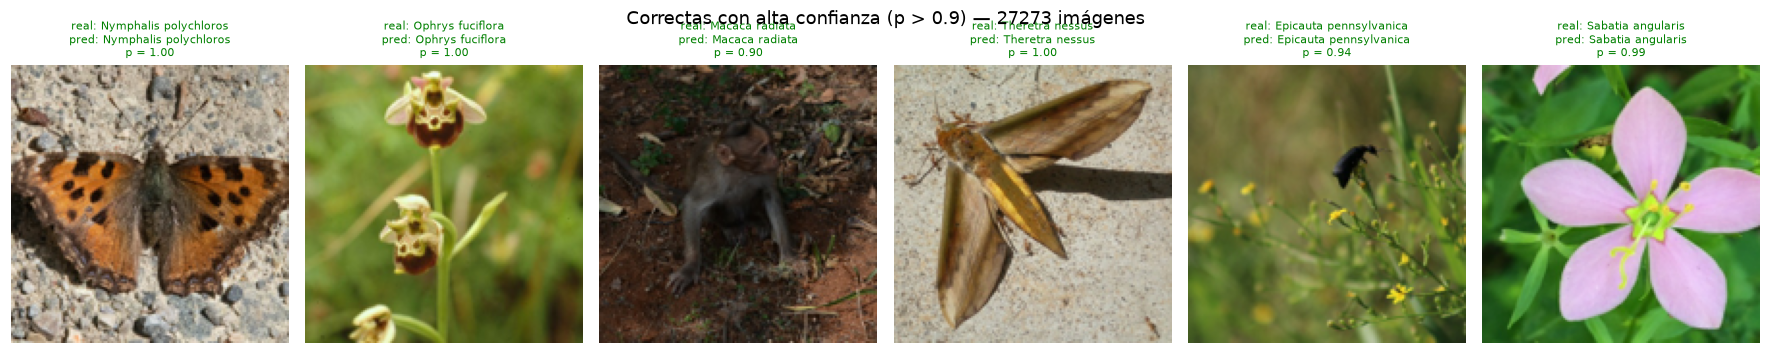

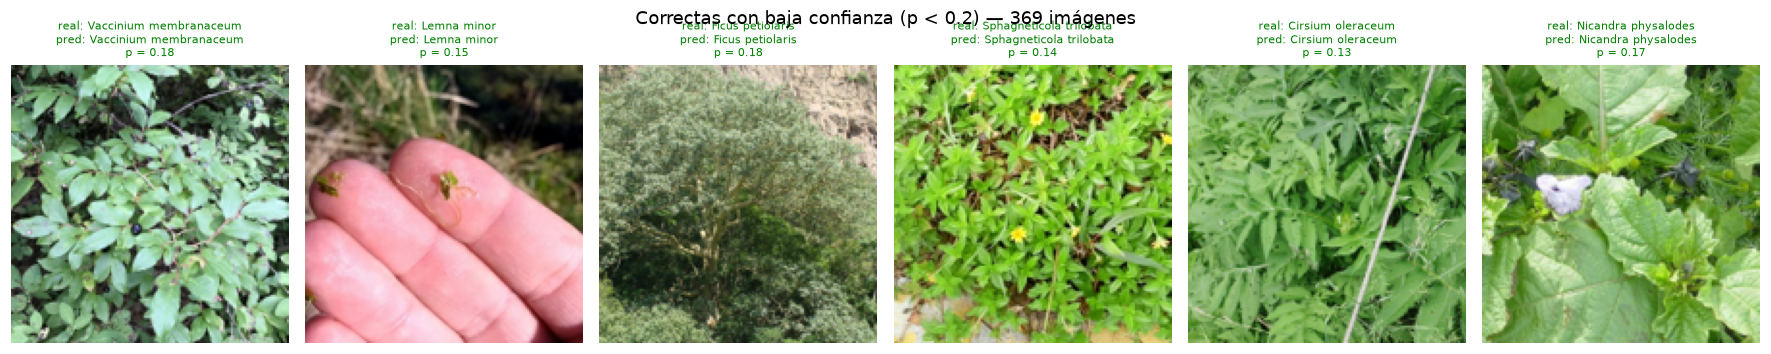

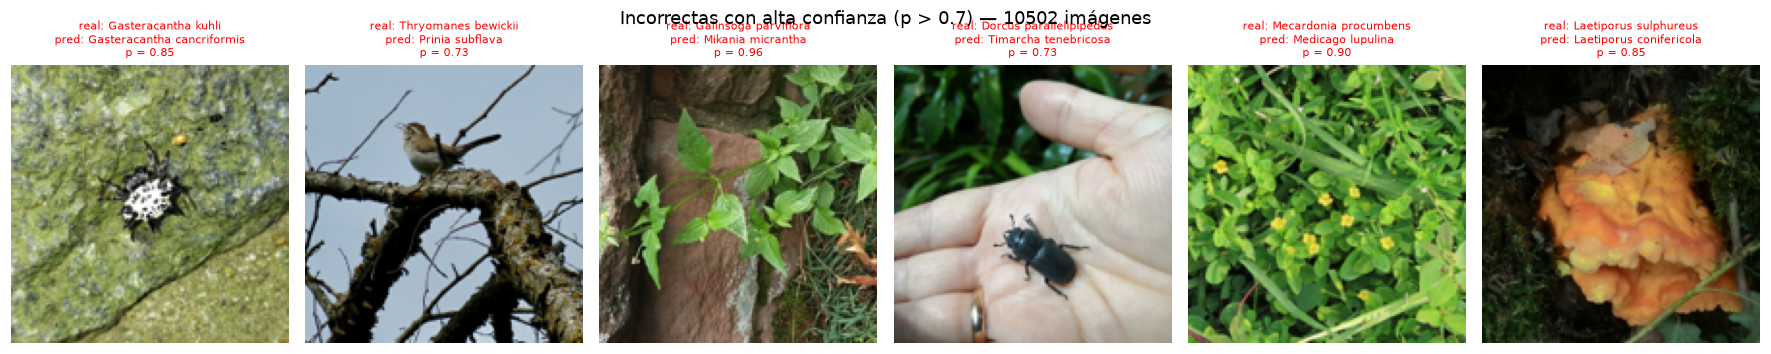

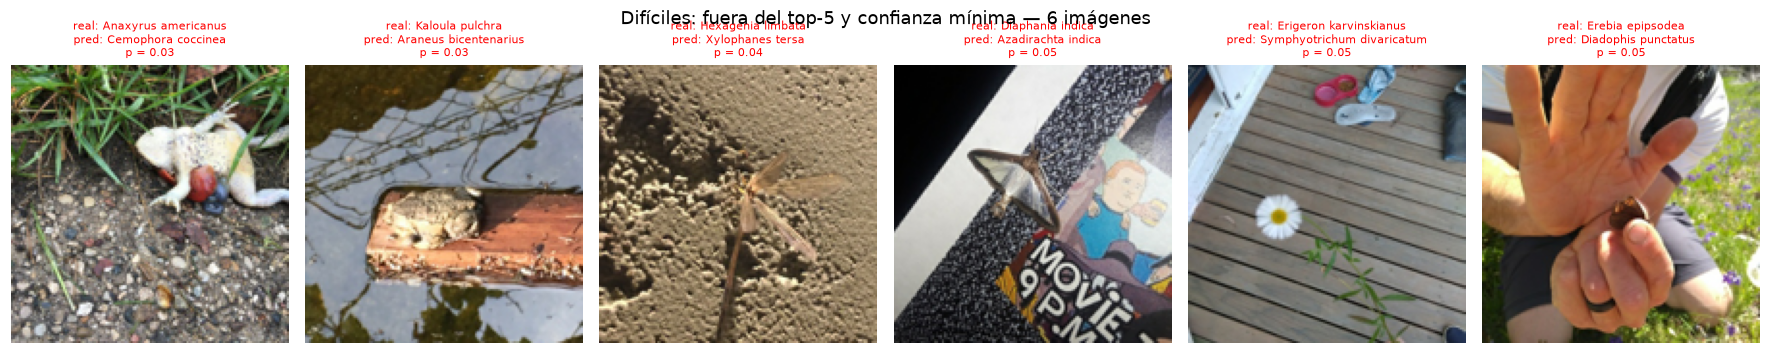

In [7]:
mm = np.memmap(CACHE / f"val_{RES_ALMACEN}.u8", dtype=np.uint8, mode="r", shape=(100_000, RES_ALMACEN, RES_ALMACEN, 3))
rng = np.random.default_rng(0)

def galeria(mask, titulo, n=6):
    idx = df.index[mask]
    if len(idx) == 0:
        return
    fig, axs = plt.subplots(1, n, figsize=(2.7 * n, 3.3))
    for ax in axs: ax.axis("off")
    for ax, i in zip(axs, rng.choice(idx, min(n, len(idx)), replace=False)):
        f = df.loc[i]
        ax.imshow(mm[p["idx_val"][i]])
        ax.set_title(f"real: {f.especie}\npred: {especies.especie.loc[f.pred]}\np = {f.conf:.2f}",
                     fontsize=7, color="green" if f.ok else "red")
    fig.suptitle(f"{titulo} — {mask.sum()} imágenes"); plt.tight_layout(); plt.show()

galeria(df.ok & (df.conf > 0.9), "Correctas con alta confianza (p > 0.9)")
galeria(df.ok & (df.conf < 0.2), "Correctas con baja confianza (p < 0.2)")
galeria(~df.ok & (df.conf > 0.7), "Incorrectas con alta confianza (p > 0.7)")
galeria(~df.ok5 & (df.conf < 0.05), "Difíciles: fuera del top-5 y confianza mínima")

### 3.4 Calibración: ¿la confianza significa algo?

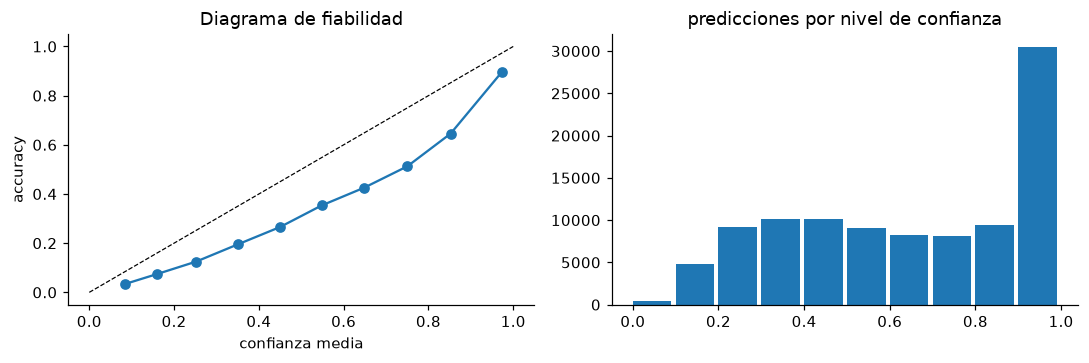

ECE (expected calibration error): 0.149


In [8]:
bins = np.linspace(0, 1, 11)
b = np.clip(np.digitize(df.conf, bins) - 1, 0, 9)
cal = df.groupby(b).agg(conf=("conf", "mean"), acc=("ok", "mean"), n=("ok", "size"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot([0, 1], [0, 1], "k--", lw=.8); ax[0].plot(cal.conf, cal.acc, "o-")
ax[0].set_xlabel("confianza media"); ax[0].set_ylabel("accuracy"); ax[0].set_title("Diagrama de fiabilidad")
ax[1].bar(bins[:-1][cal.index], cal.n, width=.09, align="edge"); ax[1].set_title("predicciones por nivel de confianza")
plt.tight_layout(); plt.show()
print(f"ECE (expected calibration error): {(cal.n * (cal.acc - cal.conf).abs()).sum() / cal.n.sum():.3f}")

### 3.5 Lectura del análisis de errores (mejor modelo: T3, 50,4 % top-1)

* **Grupos taxonómicos:** la dificultad varía el doble entre grupos. Los **insectos** son los más fáciles
  (60,8 %), junto con moluscos (57,6 %) y hongos (56,7 %). **Anfibios (29,3 %) y reptiles (31,4 %)** son
  los más difíciles: animales pequeños, crípticos (camuflados contra el fondo) y con pocas especies en
  ImageNet. Las **plantas**, el 43 % de las clases, quedan en la media (49,0 %).
* **Las especies congenéricas son más difíciles:** las especies sin otra del mismo género en el dataset
  aciertan un 56,1 %, frente a ~45,5 % las que tienen 3 o más congenéricas. Es la dificultad
  *fine-grained* medida directamente.
* **Distancia de los errores:** el **43,7 %** de los errores tiene la especie correcta dentro del top-5.
  Solo el 16,7 % de los errores cae en el mismo género y el 34,6 % dentro de la misma familia. El mayor
  bloque (29,4 %) comparte clase pero no orden: p. ej. un insecto confundido con otro insecto de otro orden.
  Solo el 6,5 % cruza de reino (planta ↔ animal), errores que probablemente vienen del fondo (un insecto
  sobre una hoja).
* **Los pares más confundidos son casi siempre del mismo género** (14 de los 15 primeros), con 5–7 de las
  10 imágenes mal clasificadas: *Burnsius albescens* / *B. communis* (dos mariposas que en la práctica se
  distinguen por genitalia o por su distribución geográfica), *Aurelia aurita* / *A. labiata*, *Erinaceus
  europaeus* / *E. roumanicus*. Son confusiones que un experto también podría cometer con una sola foto.
* **Sobreconfianza:** la confianza media es 65 % pero el acierto es 50 % (ECE = 0,149). Hay **10 502
  predicciones incorrectas con p > 0,7**. Es coherente con el 99,6 % de acierto en train: el modelo
  memorizó el conjunto de entrenamiento y aprendió a estar siempre seguro. El *label smoothing* de T4
  apunta justo a esto.
* **Ejemplos** (revisé una muestra aleatoria de 12 de cada tipo; las galerías de §3.3 muestran otras):
  - *Correctas con alta confianza:* organismos con un rasgo muy distintivo, centrados y nítidos: una
    mariquita (*Cycloneda polita*), una polilla verde (*Prasinocyma*), una babosa negra, un
    escarabajo con bandas amarillas (*Megacyllene robiniae*).
  - *Incorrectas con alta confianza:* dos patrones. **(1) Especies casi idénticas:** *Sterna hirundo* →
    *S. paradisaea* (0,91), dos charranes que se distinguen por el largo de la cola y el pico; *Agalinis
    tenuifolia* → *A. purpurea* (0,99); *Quercus buckleyi* → *Q. falcata*; un tritón por otro; un
    mejillón por otro. **(2) Organismo diminuto o camuflado:** un opilión (*Leiobunum*) casi invisible
    sobre un tronco con líquenes, predicho como hormiga; una *Bittacomorpha* (tipúlido) invisible
    entre hojas de pasto. En el caso (2) la red clasifica el fondo y no el organismo: es el problema de
    escala que el recorte central a 128 px agrava.

## 4. Pregunta de investigación, hipótesis y conclusiones

**Pregunta:** con solo 50 imágenes por especie y 128 px, ¿cuánto del rendimiento se debe al
preentrenamiento en ImageNet y cuánto al fine-tuning, y compensa su coste?

| Hipótesis | Criterio | Resultado | Veredicto |
|---|---|---|---|
| H1: T3 supera a E04 (desde cero) | ≥ 15 pp top-1 | +12,8 pp (50,4 % frente a 37,6 %) | **rechazada** (la mejora es clara, pero menor) |
| H2: T3 supera a T1 (congelado) | ≥ 5 pp top-1 | +23,8 pp (50,4 % frente a 26,7 %) | **aceptada** |
| H3: logit adjustment recupera más recall minoritario que CE ponderada | recall minoritarias L4 > L3 | 8,9 % frente a 3,1 % (L2 sin corrección: 3,7 %) | **aceptada** (pero pierde lo mismo en las frecuentes) |

**Conclusiones** (con la evidencia de p2–p7):
1. **La arquitectura importa más que el tamaño:** un MLP de 18–37 M parámetros no pasa del 1 %; una
   ResNet-18 de 16 M llega al 32 %.
2. **Preentrenar y ajustar todo el backbone es lo que más aporta** (50,4 %). Pero el preentrenamiento sin
   fine-tuning es *peor* que entrenar desde cero (26,7 % frente a 37,6 %): los rasgos de ImageNet a 128 px
   no bastan para especies.
3. **El fine-tuning parcial es el punto eficiente:** 72 % de la mejora a ~40 % del coste del completo.
4. **Optimización:** SGD+momentum es robusto al lr (y el mejor, con lr 0,5). Adam lo iguala con su lr de
   libro, pero es muy sensible a él. Sin momentum, SGD rinde la mitad.
5. **Regularización:** BN (+13 pp) >> aumento (+5–8) > weight decay (+3) > dropout (≈0).
6. **Arquitecturas:** EfficientNet-B0 iguala a ResNet-50 (37,0 % frente a 37,6 %) con 10 veces menos FLOPs,
   pero solo es 2 veces más rápida en GPU: los FLOPs no predicen el tiempo real.
7. **Long-tail:** el desbalance hunde el recall de las minoritarias del 51 % al 3,7 %. Solo *logit
   adjustment* lo mitiga (8,9 %). Reponderar la pérdida o sobremuestrear no sirve cuando la red memoriza
   el conjunto de entrenamiento (98–99 % de train top-1).

**Limitaciones:**
* Resolución de 128 px (almacenada a 144, recorte central cuadrado): pierde detalle fine-grained y
  penaliza el transfer desde 224 px.
* Una semilla por experimento: diferencias < ~0,5 pp (T3 frente a T4, E03 frente a E09) no son concluyentes.
* 16 épocas: varias curvas no se aplanaron (desde cero, aumento fuerte). El ranking podría cambiar con más
  entrenamiento.
* La misma validación se usa para early stopping y para el reporte: sesgo optimista leve.
* Los jobs corrieron en GPUs distintas (A6000 y porciones de A100): los tiempos solo son comparables
  dentro de la misma GPU.
* Los barridos de las Partes 4–5 usan ResNet-18; sus conclusiones podrían no transferirse a ResNet-50
  preentrenada.